# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 13 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada RESNET

## 1. Importe de Librerias

In [9]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2

import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [11]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-22 10:26:01.949341


## 2. Definción de Rutas y Parámetros

In [14]:
data_dir = 'Datos Finales'  # Reemplaza con la ruta real
metadata_file = 'Metadatos_Finales.csv' # Reemplaza con la ruta real
image_height = 224
image_width = 224
batch_size = 32
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [17]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Estado_Español' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta_Estado_Español'.")
    class_names = metadata['Planta_Estado_Español'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 18 clases: ['Yuca_Enferma', 'Yuca_Saludable', 'Fresa_Saludable', 'Papa_Enferma', 'Maíz_Saludable', 'Tomate_Enferma', 'Manzana_Enferma', 'Maíz_Enferma', 'Tomate_Saludable', 'Manzana_Saludable', 'Fresa_Enferma', 'Papa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Fríjol_Enferma', 'Coliflor_Saludable', 'Fríjol_Saludable', 'Pepino Cohombro_Enferma']


In [19]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Estado_Español'])
train.shape, test.shape

((42354, 12), (10589, 12))

## 4. Crear un generador de datos

In [22]:
# Crear el generador de imágenes
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 33880 validated image filenames belonging to 18 classes.
Found 8470 validated image filenames belonging to 18 classes.


## 5. Cargar el modelo ResNet50 preentrenado (sin la capa superior de clasificación)

In [25]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

## 6. Congelar las capas convolucionales base

In [28]:
for layer in base_model.layers:
    layer.trainable = False

## 7. Añadir una nueva capa de clasificación personalizada

In [31]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Puedes añadir más capas densas aquí si lo deseas
# x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

## 8. Crear el modelo final

In [34]:
model = Model(inputs=base_model.input, outputs=predictions)

## 9. Compilar el modelo para fine-tuning de la última capa

In [37]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [39]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,624,594 (90.12 MB)

 Trainable params: 36,882 (144.07 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 10. Entrenar el modelo con la última capa descongelada

In [42]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=100,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [44]:
epochs_fine_tune = 20  # Define el número de épocas para el fine-tuning

In [59]:
print("Comenzando el entrenamiento de la última capa...")
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs_fine_tune,
    callbacks=[early_stopping, reduce_lr],
    verbose = 1
)

Comenzando el entrenamiento de la última capa...
Epoch 1/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1446s 1s/step - accuracy: 0.6106 - loss: 1.5380 - val_accuracy: 0.6355 - val_loss: 1.3481 - learning_rate: 0.0010
Epoch 2/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 296s 279ms/step - accuracy: 0.6250 - loss: 1.4187 - val_accuracy: 0.6351 - val_loss: 1.3465 - learning_rate: 0.0010
Epoch 3/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1496s 1s/step - accuracy: 0.6389 - loss: 1.2946 - val_accuracy: 0.6598 - val_loss: 1.2228 - learning_rate: 0.0010
Epoch 4/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 299s 282ms/step - accuracy: 0.6562 - loss: 1.1925 - val_accuracy: 0.6624 - val_loss: 1.2238 - learning_rate: 0.0010
Epoch 5/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1535s 1s/step - accuracy: 0.6601 - loss: 1.2067 - val_accuracy: 0.6648 - val_loss: 1.1576 - learning_rate: 0.0010
Epoch 6/20
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 305s 288ms/step - accuracy: 0.6250 - loss: 1.0892 - val_accuracy: 0.6641 - val_loss: 1.1607 - learning_rate: 0.0010
Epoch 7/2

In [60]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-22 15:32:24.008609
Duración: 5:06:22.059268


## 11. Opcional: Descongelar algunas de las últimas capas del modelo base para un fine-tuning más profundo

In [62]:
#unfreeze_layers = 3  # Número de capas a descongelar (contando desde la última convolucional)

#for layer in base_model.layers[-unfreeze_layers:]:
#    layer.trainable = True


## 12. Opcional: Recompilar el modelo después de descongelar las capas

In [64]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Usar un learning rate menor
#              loss='categorical_crossentropy',
#              metrics=['accuracy'])

## 13. Opcional: Entrenar el modelo con las capas descongeladas

In [66]:
#epochs_deep_fine_tune = 10  # Define el número de épocas para el fine-tuning profundo

#print(f"\nComenzando el fine-tuning profundo de las últimas {unfreeze_layers} capas...")
#history_deep_fine_tune = model.fit(
#    train_generator,
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,
#    validation_data=validation_generator,
#    validation_steps=validation_generator.samples // validation_generator.batch_size,
#    epochs=epochs_deep_fine_tune,
#    verbose = 1
#)

## 14. Evaluar el modelo final

In [68]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
265/265 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.7263 - loss: 0.9274
Pérdida en la validación: 0.9348
Precisión en la validación: 0.7224


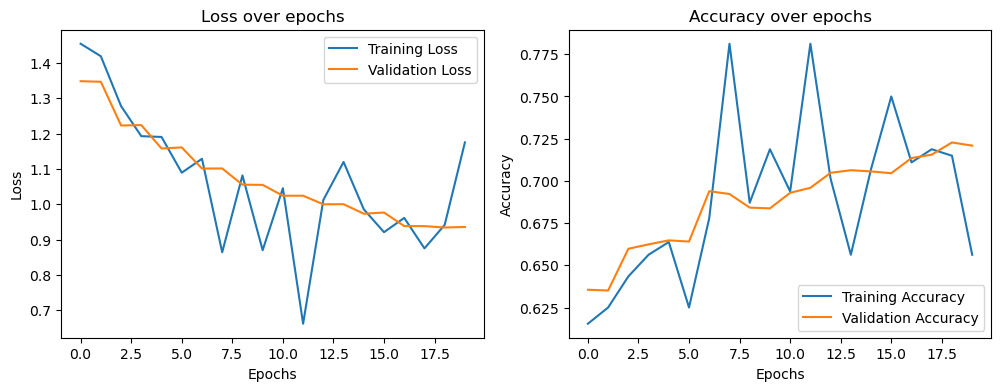

In [69]:
# Acceder a los datos de pérdida y precisión
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
accuracy = history_fine_tune.history['accuracy']
val_accuracy = history_fine_tune.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [70]:
epochs = list(range(1, 21))
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0       1        1.454116         1.348061           0.615398   
1       2        1.418690         1.346467           0.625000   
2       3        1.277532         1.222776           0.643406   
3       4        1.192503         1.223795           0.656250   
4       5        1.190295         1.157639           0.663791   
5       6        1.089238         1.160701           0.625000   
6       7        1.128515         1.100894           0.677943   
7       8        0.864002         1.101135           0.781250   
8       9        1.081495         1.055274           0.687072   
9      10        0.869870         1.054661           0.718750   
10     11        1.045249         1.023981           0.693778   
11     12        0.661806         1.024022           0.781250   
12     13        1.011914         0.999690           0.701253   
13     14        1.119530         1.000070           0.656250   
14     15        0.985583

In [71]:
# Accuracy final en entrenamiento
val_loss = history_fine_tune.history['val_loss'][-1]

In [72]:
print('Perdida final en Train:', history_fine_tune.history['loss'][-1])
print("Pérdida final en Validation:", history_fine_tune.history['val_loss'][-1])


print("Accuracy final en Train:", history_fine_tune.history['accuracy'][-1])
print("Accuracy final en Validation:", history_fine_tune.history['val_accuracy'][-1])

Perdida final en Train: 1.1749553680419922
Pérdida final en Validation: 0.935654878616333
Accuracy final en Train: 0.65625
Accuracy final en Validation: 0.7208806872367859


## 15. Testeo del Modelo

In [74]:
test.Planta_Estado_Español = test.Planta_Estado_Español.astype('str')

test_generator = datagen.flow_from_dataframe(test,
                         directory = data_dir,
                         x_col = "image_id",
                         y_col = "Planta_Estado_Español",
                         target_size = (image_height,image_width),
                         batch_size = 1,
                         shuffle=False,
                         class_mode = "categorical")

Found 10589 validated image filenames belonging to 18 classes.


In [75]:
# Evaluar sobre el set de test
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator)) 

print(f'🔎 Pérdida en test: {test_loss:.4f}')
print(f'✅ Precisión en test: {test_accuracy:.2%}')

10589/10589 ━━━━━━━━━━━━━━━━━━━━ 612s 58ms/step - accuracy: 0.7180 - loss: 0.9387
🔎 Pérdida en test: 0.9363
✅ Precisión en test: 72.05%


In [76]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

10589/10589 ━━━━━━━━━━━━━━━━━━━━ 610s 58ms/step


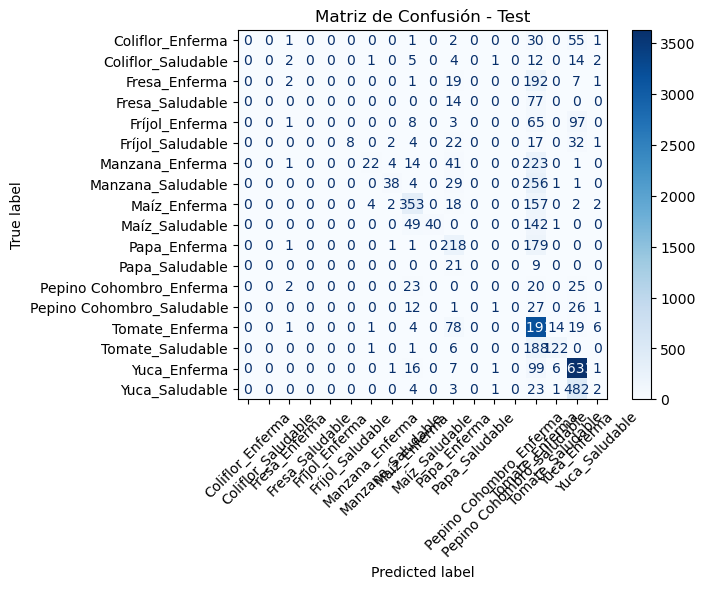

In [77]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

In [78]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7205


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


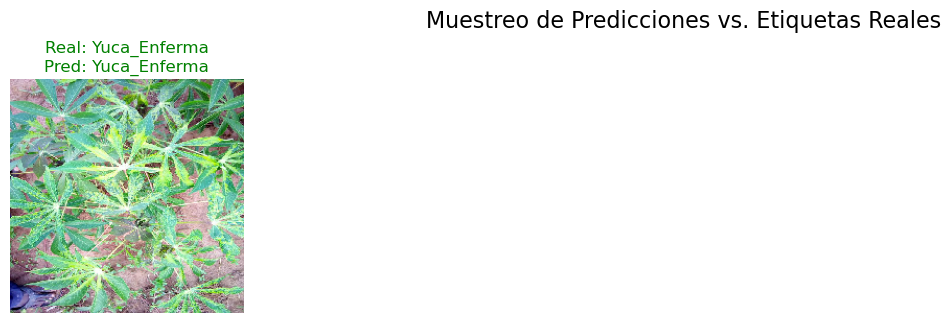

In [79]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

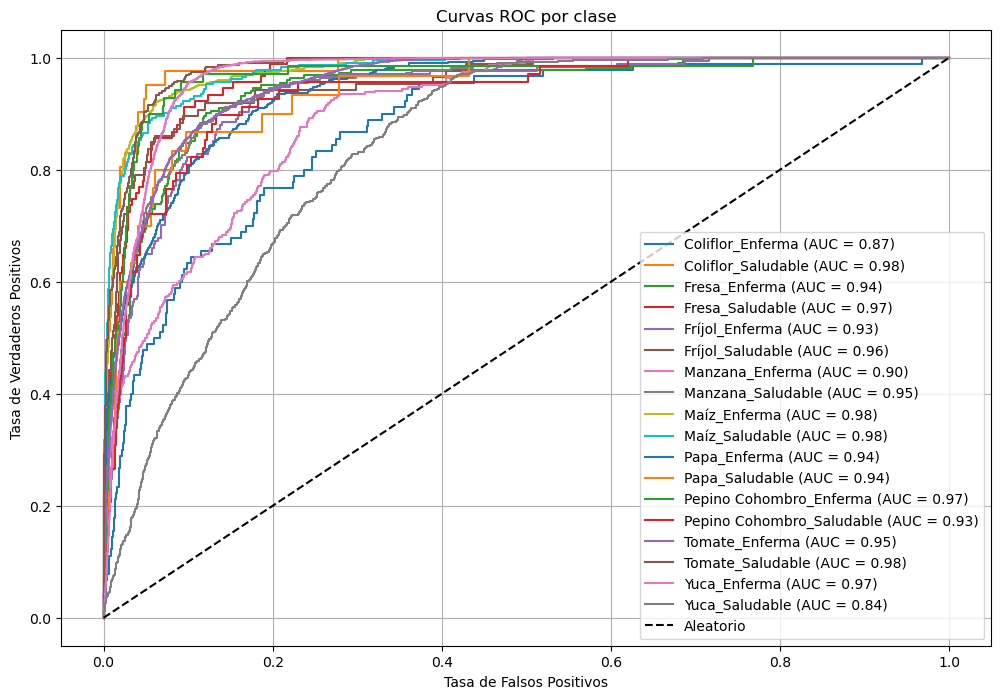

In [80]:
# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [81]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.9432
AUC Micro promedio: 0.9730


In [82]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.7205
F1 Score (macro): 0.2327
F1 Score (micro): 0.7205
F1 Score (weighted): 0.6471

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.00      0.00      0.00        90
       Coliflor_Saludable       0.00      0.00      0.00        41
            Fresa_Enferma       0.18      0.01      0.02       222
          Fresa_Saludable       0.00      0.00      0.00        91
           Fríjol_Enferma       0.00      0.00      0.00       174
         Fríjol_Saludable       1.00      0.09      0.17        86
          Manzana_Enferma       0.76      0.07      0.13       306
        Manzana_Saludable       0.79      0.12      0.20       329
             Maíz_Enferma       0.71      0.66      0.68       538
           Maíz_Saludable       1.00      0.17      0.29       232
             Papa_Enferma       0.45      0.55      0.49       400
           Papa_Saludable       0.00      0.00      0.00       

## 16. Guardar el modelo entrenado

In [83]:
model.save('modelo_10_1_resnet50_PlantaEstado_SinDataAugmentation_Parmas_UNet.h5')

In [84]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-22 15:57:42.552763
Duración: 5:31:40.603422


In [85]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_10_1_resnet50_PlantaEstado_SinDataAugmentation_Parmas_UNet1.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Coliflor_Enferma', 1: 'Coliflor_Saludable', 2: 'Fresa_Enferma', 3: 'Fresa_Saludable', 4: 'Fríjol_Enferma', 5: 'Fríjol_Saludable', 6: 'Manzana_Enferma', 7: 'Manzana_Saludable', 8: 'Maíz_Enferma', 9: 'Maíz_Saludable', 10: 'Papa_Enferma', 11: 'Papa_Saludable', 12: 'Pepino Cohombro_Enferma', 13: 'Pepino Cohombro_Saludable', 14: 'Tomate_Enferma', 15: 'Tomate_Saludable', 16: 'Yuca_Enferma', 17: 'Yuca_Saludable'}
